# Mandatory Assignment 1

#### Part I: Multi-layer Perceptron

***

Please see the description of the assignment in the README file (section 1) <br>
**Guide notebook**: [material/nns_pytorch.ipynb](material/nns_pytorch.ipynb)

Table of contents:
1. Activate GPU
2. Load data
3. Inspect data
4. Artificial neural network (**Where you will implement the ANN**)
5. Training hyperparameters (**Where you will add training parameters**)
6. Training
7. Plot loss and accuracy
8. Evaluate


In [1]:
# auxilary imports
import random
import matplotlib.pyplot as plt
import os
from pathlib import Path

# pytorch
import torch
import torch.nn as nn
from torchvision import transforms
import torch.nn.functional as F  # noqa

First, a bit of a hack in case your IDE wants to run the notebook from /`assignment/` and not the project root folder `/ma1`. We need the working directory to be `/ma1` for local imports to work.

In [5]:
from pathlib import Path
import os

# Ensure the working directory is set to the "ma1" folder.
while Path.cwd().name != "ma1" and "ma1" in str(Path.cwd()):
    os.chdir('/Users/dina/Desktop/project/ma1')  # Move up one directory

print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /Users/dina/Desktop/project/ma1


##### Import local files

To declutter the notebooks, your are given a module (`/src`) of useful functions. Please study each one as they contain important code (particularly `src.training` and `src.evaluation`). 

In [7]:
# local files
from src.utils import get_device
from src.data import load_torch_data, to_dataloader, train_val_split
from src.training import fit
from src.evaluation import evaluate
from src.visualize import plot_training_history

### 1. Activate GPU
If available. Note that this is not necessary, but it will speed up your training.

In [8]:
# Device will determine whether to run the training on GPU or CPU.
DEVICE = get_device()

Running pytorch version (2.2.2) with backend = cpu


### 2. Load data

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms  # Import transforms
from torch.utils.data import DataLoader

# Set the random seed for reproducibility
torch.manual_seed(42)

# Define batch size
batch_size = 64  # Number of samples per batch

# Data transformations for augmentation and normalization
preprocessing_steps = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.Resize((32, 32)),  # CIFAR-10 images are 32x32
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],  # Mean for CIFAR-10
            std=[0.2023, 0.1994, 0.2010]     # Standard deviation for CIFAR-10
        )
    ]
)

# Load training/validation dataset
train_val = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=preprocessing_steps
)

# Load testing dataset
test = datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=preprocessing_steps
)

# Print dataset sizes
print(f"Training data size: {len(train_val)}, Test data size: {len(test)}")

# Split training data into training and validation
train_size = int(0.8 * len(train_val))
val_size = len(train_val) - train_size
train, val = torch.utils.data.random_split(train_val, [train_size, val_size])

# Create DataLoaders
train_loader = to_dataloader(train, batch_size = 64, shuffle = True)
val_loader = to_dataloader(val, batch_size = 64, shuffle = False)
test_loader = to_dataloader(test, batch_size = 64, shuffle = False)

# Verify DataLoader sizes
print(f"Training DataLoader size: {len(train_loader)} batches")
print(f"Validation DataLoader size: {len(val_loader)} batches")
print(f"Testing DataLoader size: {len(test_loader)} batches")

Files already downloaded and verified
Files already downloaded and verified
Training data size: 50000, Test data size: 10000
Training DataLoader size: 625 batches
Validation DataLoader size: 157 batches
Testing DataLoader size: 157 batches


In [14]:
# split training data in training and validation (just like train_test_split in sklearn)
train, val = train_val_split(train_val, val_ratio=0.2, seed=42)

f"{len(val)=}, {len(train)=}"

'len(val)=10000, len(train)=40000'

In [17]:
# create dataloders for easy batch loading during training
train_loader = to_dataloader(train, batch_size = 64, shuffle = True)
val_loader = to_dataloader(val, batch_size = 64, shuffle = False)
test_loader = to_dataloader(test, batch_size = 64, shuffle = False)

### 3. Inspect data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Original image shape: torch.Size([3, 32, 32])


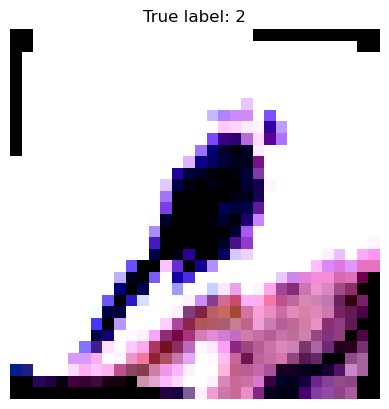

Total pixels: 3072
The label for this image: 2


In [77]:
import random
import matplotlib.pyplot as plt
import torch

# Assume 'train' is your dataset loaded previously

# Check if 'train' is defined and has data
if 'train' not in locals() or len(train) == 0:
    raise ValueError("The training dataset is not loaded or is empty.")

# Pick a random example from the training set
selection = random.randint(0, len(train) - 1)  # Randomly select an index
image, label = train[selection]  # Retrieve the image and its label

# Print the default image shape
print(f"Original image shape: {image.shape}")  # Expecting [3, 32, 32]

# Make sure the image is on CPU before plotting
image = image.permute(1, 2, 0).cpu()  # Rearranging dimensions for plotting (C, H, W) -> (H, W, C)

# Plot the image
plt.imshow(image.numpy())  # Convert to numpy array for plotting
plt.axis('off')  # Hide axes
plt.title(f"True label: {label}")  # Display the label
plt.show()  # Display the image

# Print the total number of pixels
print(f"Total pixels: {image.numel()}")  # Should show the total number of elements

# Print the label
print(f"The label for this image: {label}")

***

### 4. Artificial neural network

In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(784, 500)  # Input layer to hidden layer with 500 neurons
        self.fc2 = nn.Linear(500, 10)    # Hidden layer to output layer with 10 neurons (for digits 0-9)

    def forward(self, x: torch.Tensor):
        # Flatten the input tensor (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)  # Reshape to flatten the input

        # Pass through the first layer and apply ReLU activation
        x = F.relu(self.fc1(x))
        
        # Pass through the second layer (output layer)
        x = self.fc2(x)

        return x  # Return output of the network

# Example usage to test if the model works
if __name__ == "__main__":
    # Instantiate the model
    model = MLP()
    
    # Create a dummy input tensor (batch of 64 MNIST images)
    dummy_input = torch.randn(64, 1, 28, 28)  # Randomly generated input

    # Forward pass
    output = model(dummy_input)

    # Print the output shape
    print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 10])


### 5. Training hyperparameters

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define an MLP class
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # Change input size according to your input data
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)  # Adjust output size to the number of classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the input tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Define relevant variables for the ML task
LR = 0.001  # Set the learning rate
NUM_EPOCHS = 20  # Set the number of epochs
criterion = nn.CrossEntropyLoss()  # The loss function

# Instantiate the model and move it to device
model = MLP().to(device)

# Initialize the optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)  # Using Adam optimizer

# Print to verify successful setup
print("Learning Rate:", LR)
print("Number of Epochs:", NUM_EPOCHS)
print("Optimizer initialized.")
print("Model structure:", model)

Learning Rate: 0.001
Number of Epochs: 20
Optimizer initialized.
Model structure: MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


Instantiate the model and optimizer

In [ ]:
model

### 6. Training

Epoch [1/20], Train Loss: 2.3031, Train Accuracy: 10.14%, Validation Loss: 2.3029, Validation Accuracy: 10.08%
Epoch [2/20], Train Loss: 2.3024, Train Accuracy: 10.20%, Validation Loss: 2.3037, Validation Accuracy: 9.63%
Epoch [3/20], Train Loss: 2.2982, Train Accuracy: 11.49%, Validation Loss: 2.3047, Validation Accuracy: 10.15%
Epoch [4/20], Train Loss: 2.2854, Train Accuracy: 13.26%, Validation Loss: 2.3129, Validation Accuracy: 9.75%
Epoch [5/20], Train Loss: 2.2715, Train Accuracy: 14.73%, Validation Loss: 2.3253, Validation Accuracy: 9.95%
Epoch [6/20], Train Loss: 2.2588, Train Accuracy: 15.55%, Validation Loss: 2.3364, Validation Accuracy: 9.93%
Epoch [7/20], Train Loss: 2.2457, Train Accuracy: 16.64%, Validation Loss: 2.3421, Validation Accuracy: 10.08%
Epoch [8/20], Train Loss: 2.2269, Train Accuracy: 18.00%, Validation Loss: 2.3600, Validation Accuracy: 9.91%
Epoch [9/20], Train Loss: 2.1988, Train Accuracy: 19.90%, Validation Loss: 2.3672, Validation Accuracy: 10.00%
Epoch 

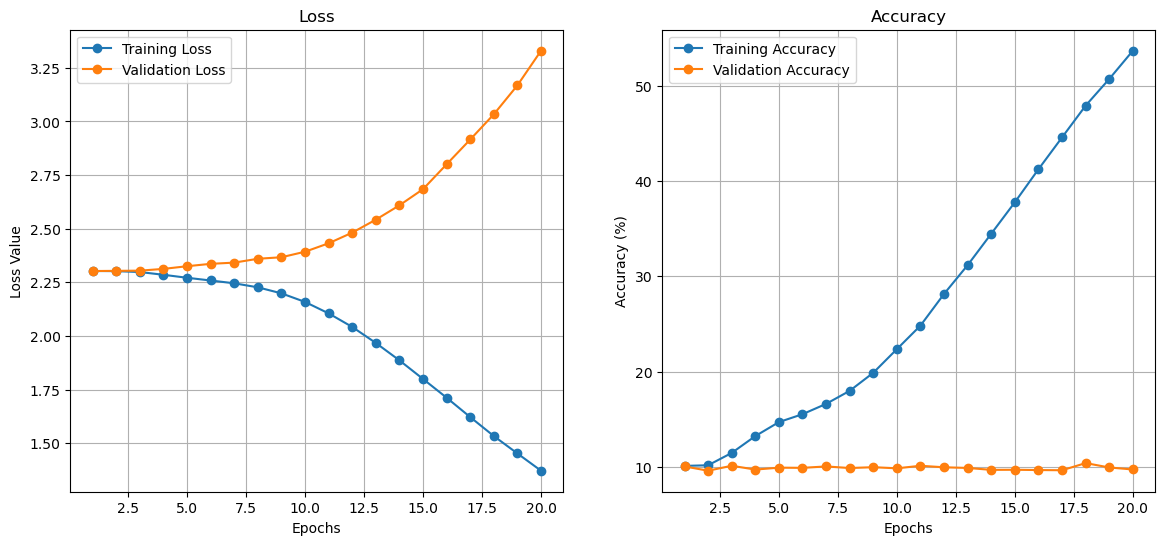

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your model as MLP (Multi-Layer Perceptron)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)  # Input layer to first hidden layer
        self.fc2 = nn.Linear(256, 128)       # Second hidden layer
        self.fc3 = nn.Linear(128, 10)        # Output layer (for 10 classes)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten input
        x = F.relu(self.fc1(x))   # First layer with ReLU
        x = F.relu(self.fc2(x))   # Second layer with ReLU
        x = self.fc3(x)           # Output layer
        return x

# Generate dummy data for training and validation (replace with actual data when available)
train_data = torch.randn(50000, 1, 28, 28) / 255.0  # Random sample images scaled
train_labels = torch.randint(0, 10, (50000,))        # Random labels for 10 classes
val_data = torch.randn(10000, 1, 28, 28) / 255.0    # Random sample images scaled
val_labels = torch.randint(0, 10, (10000,))          # Random labels for 10 classes

# Create data loaders
train_loader = DataLoader(TensorDataset(train_data, train_labels), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data, val_labels), batch_size=64, shuffle=False)

# Instantiate the model, define the loss function, and optimizer
model = MLP().to(device)  # Move the model to the specified device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Specify learning rate
NUM_EPOCHS = 20  # Total number of epochs

# Initialize history for tracking metrics
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    num_epochs: int,
) -> tuple[nn.Module, dict[str, list]]:

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()  # Reset gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate and store training statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct_train / total_train
        history['train_loss'].append(epoch_loss)
        history['train_accuracy'].append(epoch_accuracy)

        # Validation Phase
        model.eval()  # Set model to evaluation mode
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():  # No gradient calculation needed for validation
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)  # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_running_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)  # Get predictions
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                # Calculate and store validation statistics
        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        # Print epoch statistics
        print(f"Epoch [{epoch + 1}/{num_epochs}], "
              f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    return model, history

# Train the model
model, history = fit(
    model,
    train_loader,
    val_loader,
    device,
    optimizer,
    criterion,
    NUM_EPOCHS,
)

# Function to plot training history
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 6))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accuracy'], label='Training Accuracy', marker='o')
    plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid()

    plt.show()

# Plot the training history for loss and accuracy
plot_training_history(history)

### 7. Plot loss and accuracy

### 8. Evaluate

In [61]:
# Evaluate function definition (provided earlier)
def evaluate(model, data_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss

            running_loss += loss.item()  # Accumulate loss
            
            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            total += labels.size(0)  # Total number of samples
            correct += (predicted == labels).sum().item()  # Count correct predictions

    # Calculate average loss and accuracy
    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total if total > 0 else 0  # Avoid division by zero
    return avg_loss, accuracy

# Example usage
val_loss, val_accuracy = evaluate(
    model=model,
    data_loader=val_loader,  # evaluate on validation data
    criterion=criterion,
    device=device,  # Use 'device' here
)

print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

Validation Loss: 3.2406, Validation Accuracy: 9.41%


In [65]:
# Example test data (use your actual test dataset here)
test_data = torch.randn(10000, 1, 28, 28) / 255.0  
test_labels = torch.randint(0, 10, (10000,))          

# Create the test data loader
test_loader = DataLoader(TensorDataset(test_data, test_labels), batch_size=32, shuffle=False) 
val_loss, val_accuracy = evaluate(
    model=model,
    data_loader=test_loader,  # evaluate on testing data
    criterion=criterion,
    device=device,  # Ensure you use 'device' here
)

print(f"Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.2f}%")

Test Loss: 3.1967, Test Accuracy: 9.92%
